Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


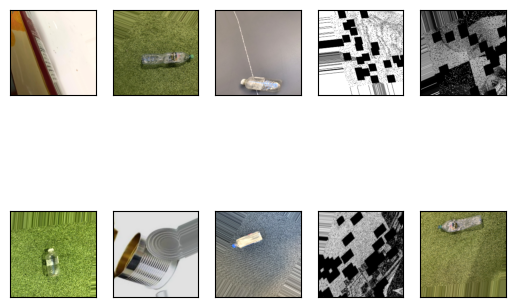

In [4]:
# %% [1] Aumento de datos con ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

# AJUSTE 1: Augmentation más suave y realista
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=15,
    zoom_range=[0.8, 1.2],       # Antes 0.5 a 1.5 (muy extremo)
    brightness_range=[0.8, 1.2], # Antes 0.4 a 1.5 (muy oscuro)
    horizontal_flip=True,
    validation_split=0.2
)

data_gen_entrenamiento = datagen.flow_from_directory(
    "dataset", target_size=(224, 224), 
    batch_size=32, shuffle=True, subset="training"
)

data_gen_validacion = datagen.flow_from_directory(
    "dataset", target_size=(224, 224), 
    batch_size=32, shuffle=True, subset="validation"
)

# Visualizar muestras
for imagen, etiqueta in data_gen_entrenamiento:
    for i in range(10):
        plt.subplot(2, 5, i+1)
        plt.xticks([]); plt.yticks([])
        plt.imshow(imagen[i])
    break
plt.show()


In [5]:
# %% [2] Transferencia de aprendizaje (Fine-Tuning)
import tensorflow as tf

mobilenetv2 = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

# AJUSTE 2: Descongelamos el modelo base para que aprenda TUS materiales
mobilenetv2.trainable = True 

modelo = tf.keras.Sequential([
    mobilenetv2,
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(), # Ayuda a estabilizar derivadas
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(2, activation='softmax')
])

# AJUSTE 3: Learning Rate bajo (0.0001) para no olvidar lo que la IA ya sabía
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,098 (9.99 MB)

 Trainable params: 2,585,474 (9.86 MB)

 Non-trainable params: 34,624 (135.25 KB)

In [6]:
# %% [3] Entrenamiento con Callbacks
import datetime

EPOCAS = 100

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

mis_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='MobileNetV2v.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
]

historial = modelo.fit(
    data_gen_entrenamiento,
    epochs=EPOCAS,
    validation_data=data_gen_validacion,
    callbacks=mis_callbacks
)

Epoch 1/100


I0000 00:00:1778390931.250253   16146 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_691083__.339


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.7295 - loss: 0.6368
Epoch 1: val_accuracy improved from None to 0.63750, saving model to MobileNetV2v.keras

Epoch 1: finished saving model to MobileNetV2v.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 133s 343ms/step - accuracy: 0.8039 - loss: 0.4616 - val_accuracy: 0.6375 - val_loss: 1.3332
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8711 - loss: 0.3078
Epoch 2: val_accuracy did not improve from 0.63750
250/250 ━━━━━━━━━━━━━━━━━━━━ 81s 320ms/step - accuracy: 0.8817 - loss: 0.2727 - val_accuracy: 0.6260 - val_loss: 1.9434
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9063 - loss: 0.2147
Epoch 3: val_accuracy improved from 0.63750 to 0.70900, saving model to MobileNetV2v.keras

Epoch 3: finished saving model to MobileNetV2v.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 90s 360ms/step - accuracy: 0.9091 - loss: 0.2111 - val_accuracy: 0.7090 - val_loss: 1.3109
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 38

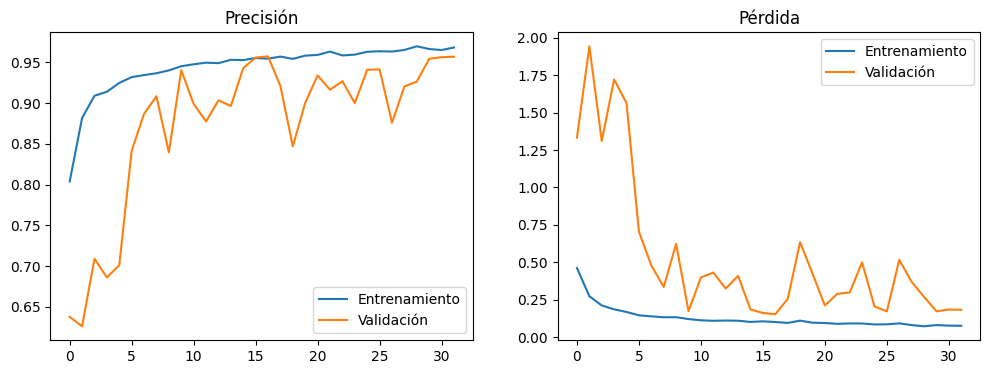

In [10]:
# %% [4] Graficas de precisión y pérdida
acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
loss = historial.history['loss']
val_loss = historial.history['val_loss']
range_epocas = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range_epocas, acc, label='Entrenamiento')
plt.plot(range_epocas, val_acc, label='Validación')
plt.title('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range_epocas, loss, label='Entrenamiento')
plt.plot(range_epocas, val_loss, label='Validación')
plt.title('Pérdida')
plt.legend()
plt.show()


Recalculando métricas correctamente...
Found 2000 images belonging to 2 classes.
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 359ms/step


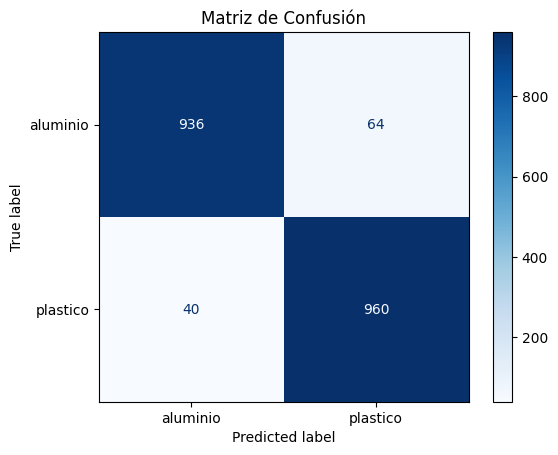

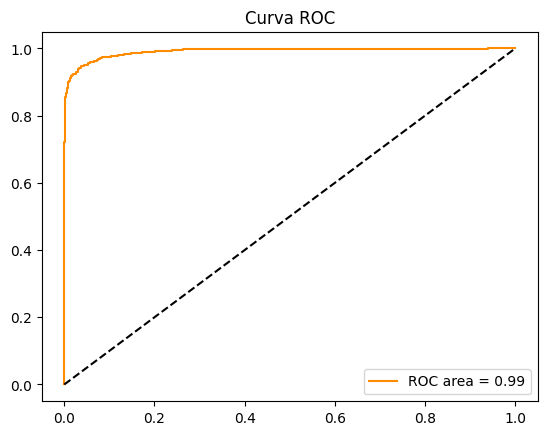

In [25]:
# %% [5] Matriz de Confusión y ROC (CORREGIDO)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

print("Recalculando métricas correctamente...")

# 1. EL FIX: Redefinimos el generador SIN SHUFFLE para la evaluación
data_gen_evaluacion = datagen.flow_from_directory(
    "dataset", 
    target_size=(224, 224), 
    batch_size=32, 
    shuffle=False, # <--- ¡ESTE ES EL SECRETO!
    subset="validation"
)

# 2. Obtenemos las etiquetas reales (que ahora sí coincidirán)
y_true = data_gen_evaluacion.classes

# 3. Hacemos las predicciones (ahora en orden)
y_pred_proba = modelo.predict(data_gen_evaluacion)
y_pred = np.argmax(y_pred_proba, axis=1)

# --- GRAFICAR MATRIZ ---
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(data_gen_evaluacion.class_indices.keys()))
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.show()

# --- GRAFICAR ROC ---
fpr, tpr, _ = roc_curve(y_true, y_pred_proba[:, 1])
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC area = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curva ROC')
plt.legend()
plt.show()


/home/gaelp/Proyecto_ia/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


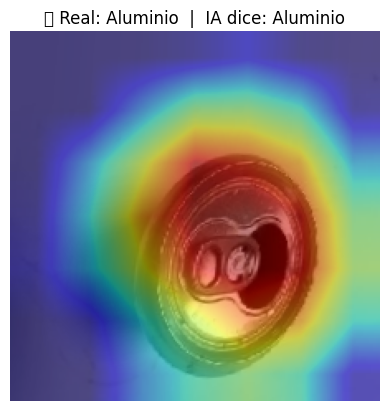

In [29]:
# %% [6] Herramienta Grad-CAM (Diagnóstico Visual con Etiquetas)
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def visualizar_gradcam(img_batch, etiqueta_real_batch, model, last_conv_layer_name='Conv_1'):
    base_model = model.layers[0]
    
    grad_model = tf.keras.models.Model(
        inputs=base_model.inputs, 
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, base_model_outputs = grad_model(img_batch)
        
        x = base_model_outputs
        for layer in model.layers[1:]:
            x = layer(x)
            
        preds = x 
        pred_index = tf.argmax(preds[0]).numpy()
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    # --- NUEVA LÓGICA DE ETIQUETAS ---
    clases = ['Aluminio', 'Plástico']
    
    # Extraemos el índice real (convierte de [0,1] a 1, o de [1,0] a 0)
    real_index = np.argmax(etiqueta_real_batch[0])
    
    nombre_real = clases[real_index]
    nombre_prediccion = clases[pred_index]
    
    # Validación visual rápida
    icono = "✅" if real_index == pred_index else "❌"

    # --- VISUALIZACIÓN ---
    plt.imshow(img_batch[0])
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
    
    # Título profesional con ambas métricas
    plt.title(f'{icono} Real: {nombre_real}  |  IA dice: {nombre_prediccion}')
    plt.axis('off')
    plt.show()

# Probar Grad-CAM pasándole tanto la imagen como su etiqueta real
img_test, etiqueta_real = next(data_gen_evaluacion)

# Nota: le pasamos img_test[0:1] para mandar solo la primera foto del lote
# y etiqueta_real[0:1] para mandar solo la etiqueta de esa foto
visualizar_gradcam(img_test[0:1], etiqueta_real[0:1], modelo)


In [22]:
# %% [7] Clasificación de una imagen externa
from PIL import Image
import requests
from io import BytesIO

url = "https://media.es.wired.com/photos/66858822d846484dcb12c64b/1:1/w_5473,h_5473,c_limit/2158735448"
def categorizar(url):
    respuesta = requests.get(url)
    img = Image.open(BytesIO(respuesta.content)).convert('RGB')
    img = np.array(img).astype(float) / 255.0
    img = cv2.resize(img, (224, 224))
    prediccion = modelo.predict(img.reshape(1, 224, 224, 3))
    clase = np.argmax(prediccion[0])
    print(f"Predicción: {clase} ({'Plástico' if clase==1 else 'Aluminio'})")
    return clase

categorizar(url)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicción: 1 (Plástico)


np.int64(1)